<a href="https://colab.research.google.com/github/MinThwMN/Datamining_Machine-Learning-Based-Sentiment-Classification-for-Mobile-Device-Reviews/blob/main/DO_AN(Khaithacdulieu_RF).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Load data + chuẩn bị folder

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import os
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/Mobile Reviews Sentiment.csv'
df = pd.read_csv(file_path, parse_dates=['review_date'])
df = df.sort_values('review_date')
os.makedirs("/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/DOAN/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/DOAN/predictions", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/DOAN/plots", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/DOAN/metrics", exist_ok=True)



Mounted at /content/drive


#2. Đọc file dữ liệu

In [ ]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 2024 to 14565
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   review_id             50000 non-null  int64         
 1   customer_name         50000 non-null  object        
 2   age                   50000 non-null  int64         
 3   brand                 50000 non-null  object        
 4   model                 50000 non-null  object        
 5   price_usd             50000 non-null  float64       
 6   price_local           50000 non-null  object        
 7   currency              50000 non-null  object        
 8   exchange_rate_to_usd  50000 non-null  float64       
 9   rating                50000 non-null  int64         
 10  review_text           50000 non-null  object        
 11  sentiment             50000 non-null  object        
 12  country               50000 non-null  object        
 13  language          

,review_id,age,price_usd,exchange_rate_to_usd,rating,review_date,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.693713,12.057946,3.123120,2024-04-20 09:24:46.080000,2.71800,2.717640,2.719620,2.713960,2.721280,62.791440,10.623820,3.644180
min,1.000000,18.000000,180.020000,0.780000,1.000000,2022-10-22 00:00:00,1.00000,1.000000,1.000000,1.000000,1.000000,45.000000,6.000000,0.000000
25%,12500.750000,23.000000,450.792500,1.000000,2.000000,2023-07-20 00:00:00,1.00000,1.000000,1.000000,1.000000,1.000000,56.000000,9.000000,2.000000
50%,25000.500000,29.000000,637.040000,1.530000,3.000000,2024-04-21 00:00:00,3.00000,3.000000,3.000000,3.000000,3.000000,63.000000,11.000000,3.000000
75%,37500.250000,36.000000,900.975000,5.700000,4.000000,2025-01-20 00:00:00,4.00000,4.000000,4.000000,4.000000,4.000000,68.000000,12.000000,5.000000
max,50000.000000,65.000000,1499.890000,83.000000,5.000000,2025-10-21 00:00:00,5.00000,5.000000,5.000000,5.000000,5.000000,82.000000,15.000000,17.000000
std,14433.901067,8.931307,310.307331,26.553332,1.248612,NaN,1.34827,1.345001,1.349208,1.343346,1.352121,8.017695,1.957239,2.432745


#3. Xóa cột không cần thiết

In [ ]:
cols_to_drop = ['review_id','customer_name','review_text', 'price_local', 'currency', 'language']

df_cleaned = df.drop(columns=cols_to_drop)
df=df_cleaned
df.head()


,age,brand,model,price_usd,exchange_rate_to_usd,rating,sentiment,country,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
2024,25,Google,Pixel 8,823.98,0.78,4,Positive,UK,2022-10-22,True,3,4,1,4,4,47,9,8,Flipkart
34,45,Samsung,Galaxy A55,1071.57,1.38,4,Positive,Canada,2022-10-22,True,4,5,5,4,2,64,12,4,Flipkart
1299,21,OnePlus,OnePlus 12,891.57,83.00,5,Positive,India,2022-10-22,True,4,4,5,4,5,71,12,7,eBay
20048,24,Realme,Realme Narzo 70,531.89,0.78,2,Negative,UK,2022-10-22,False,3,1,2,3,1,62,9,1,Amazon
39785,25,Google,Pixel 7a,720.63,83.00,5,Positive,India,2022-10-22,False,5,5,5,5,4,78,14,9,Flipkart


# 4. Trực quan hóa dữ liệu

### 4.1.  Trực quan hóa dữ liệu số

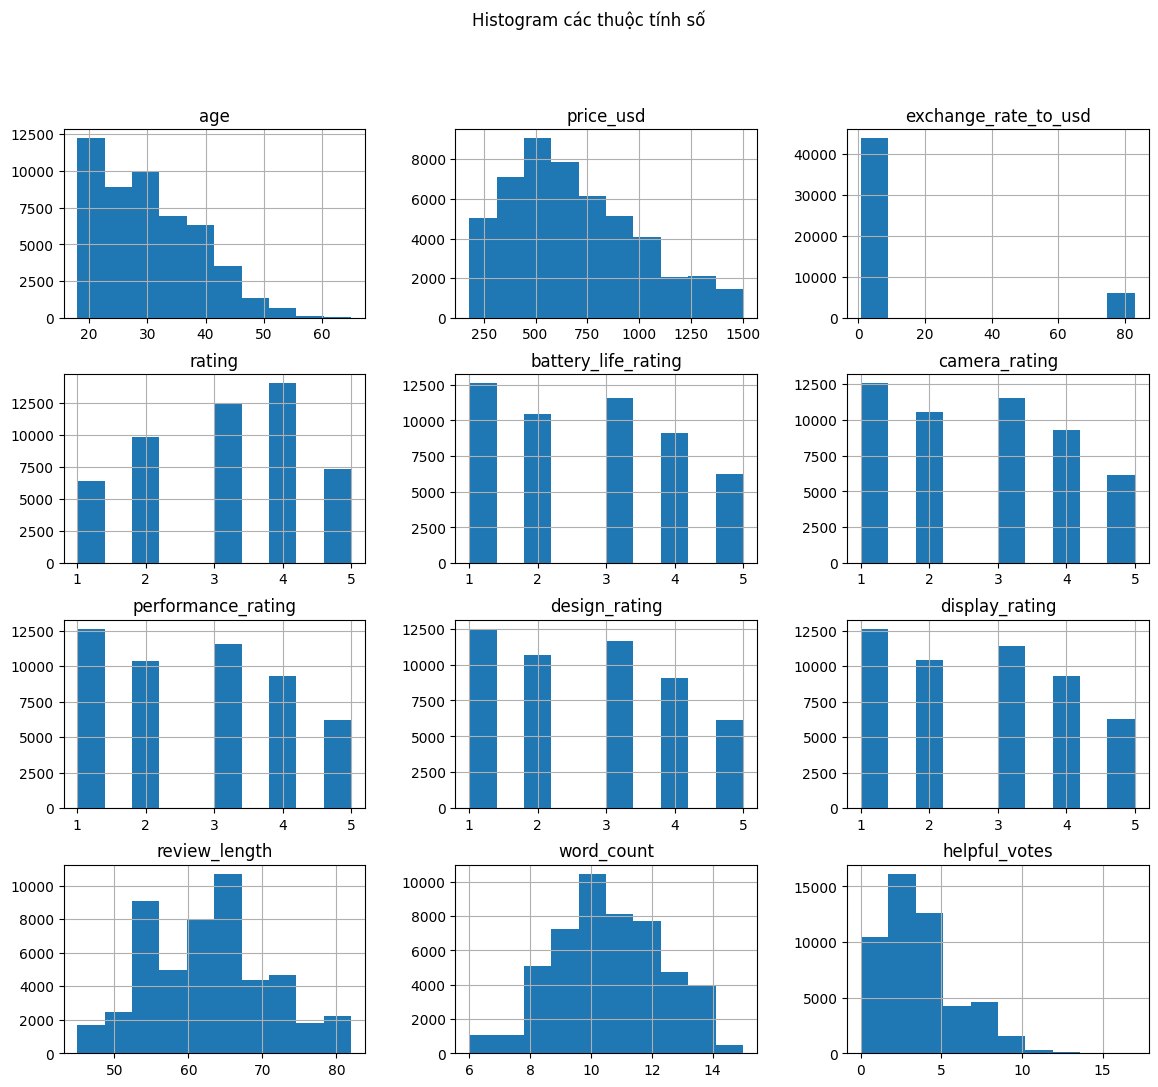

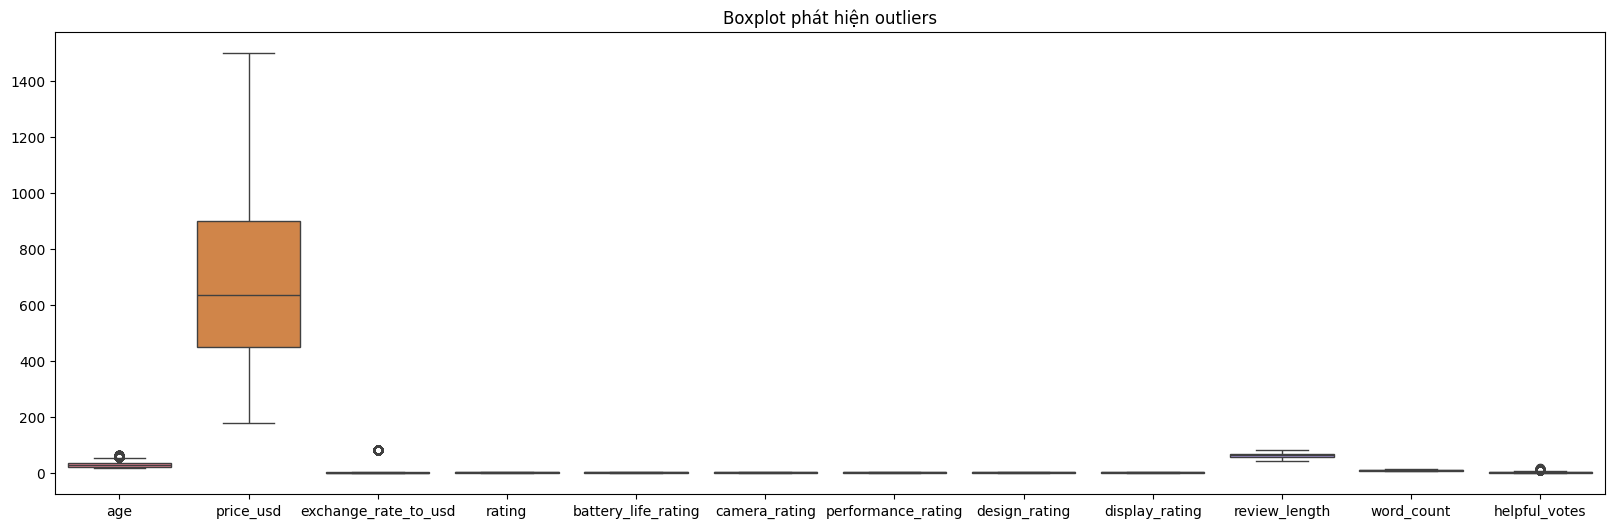

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Histogram
df[numeric_cols].hist(figsize=(14, 12))
plt.suptitle("Histogram các thuộc tính số")
plt.show()

# Boxplot để kiểm tra outliers
plt.figure(figsize=(20, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot phát hiện outliers")
plt.show()


### 4.2. Phân tích mối quan hệ giữa các biến số và mục tiêu

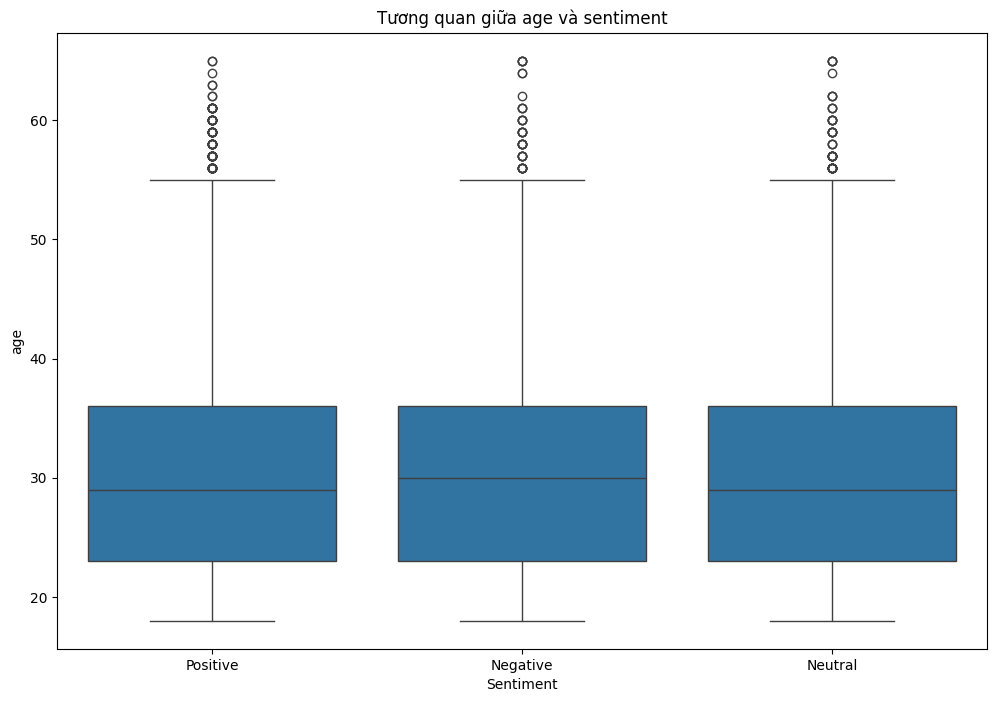

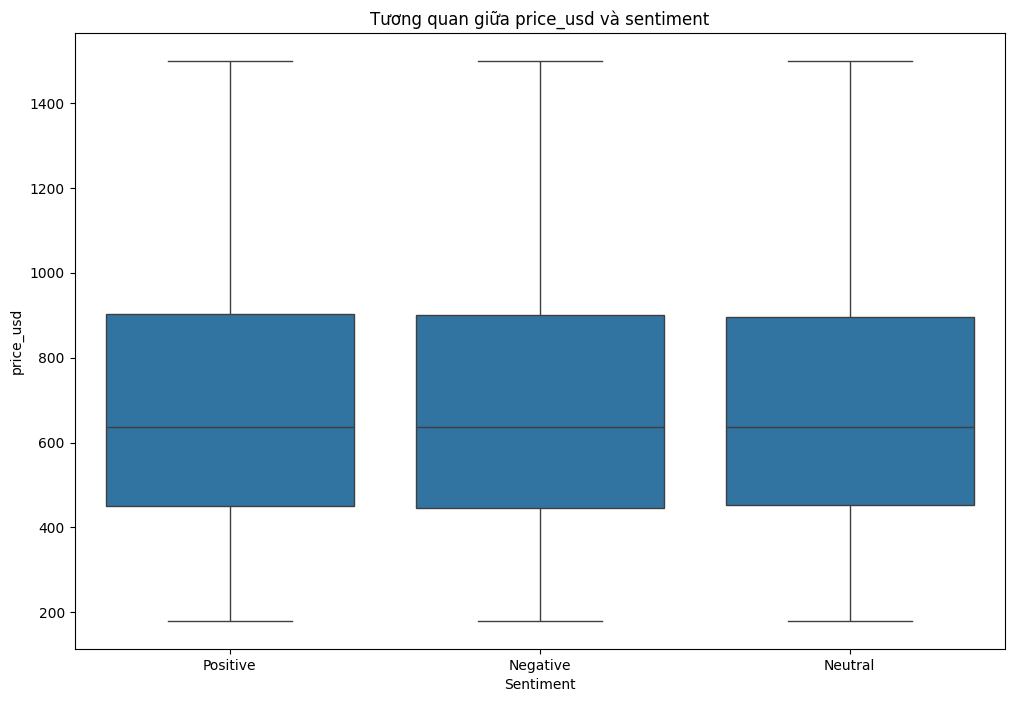

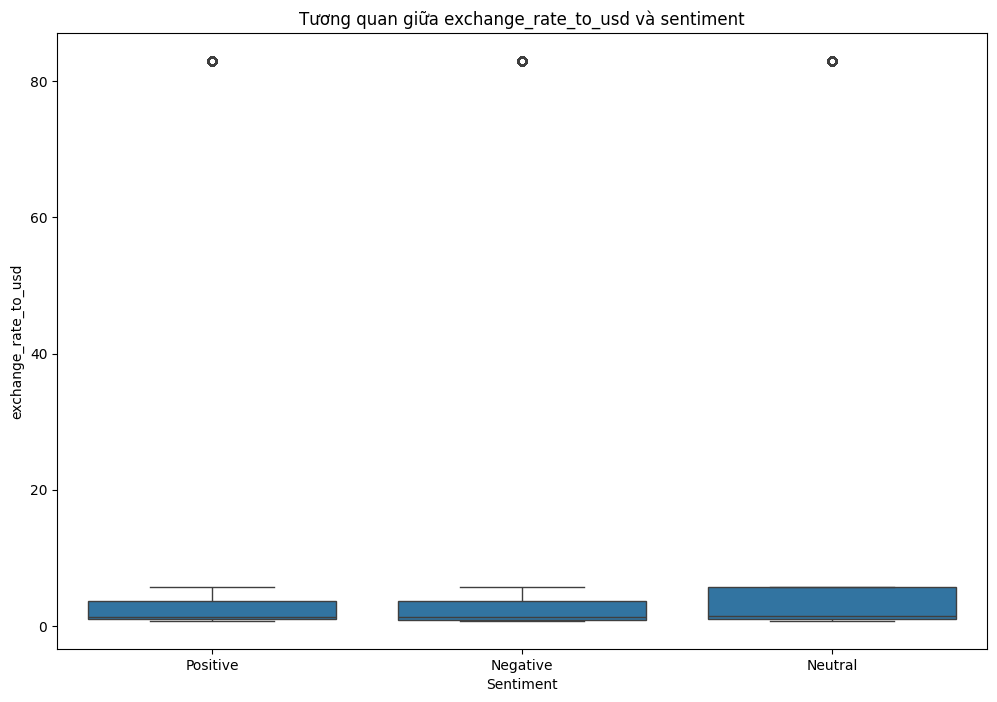

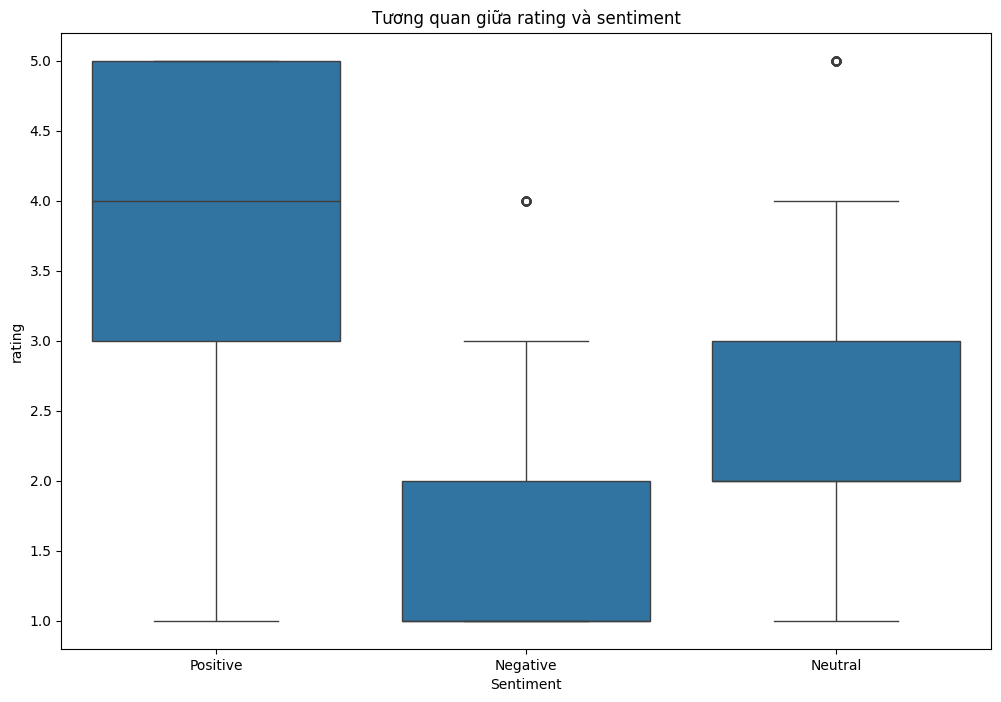

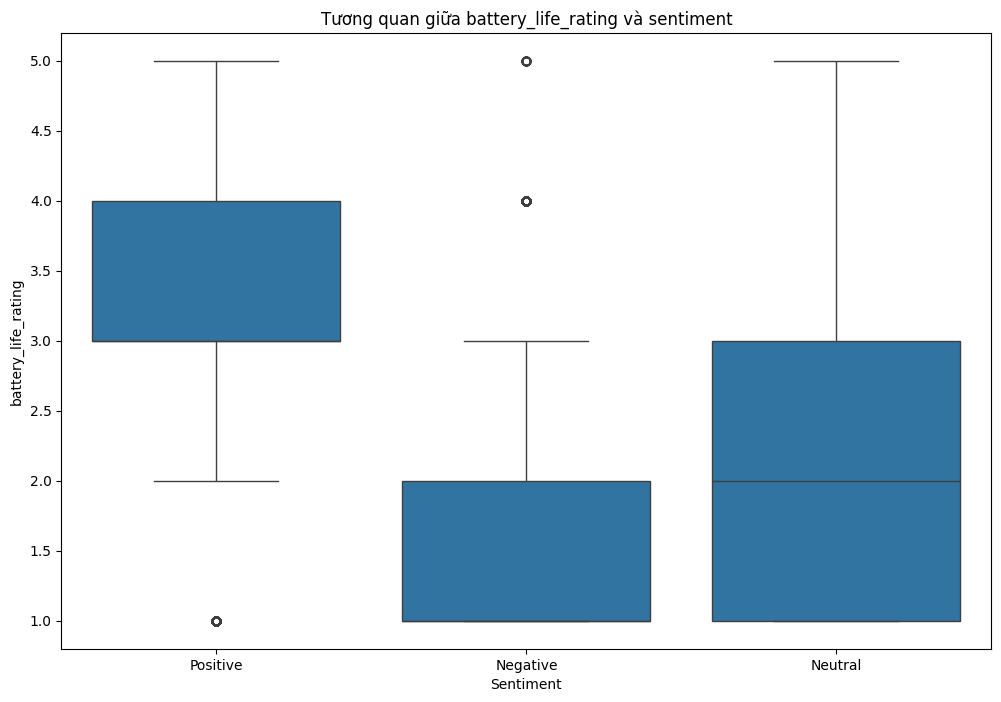

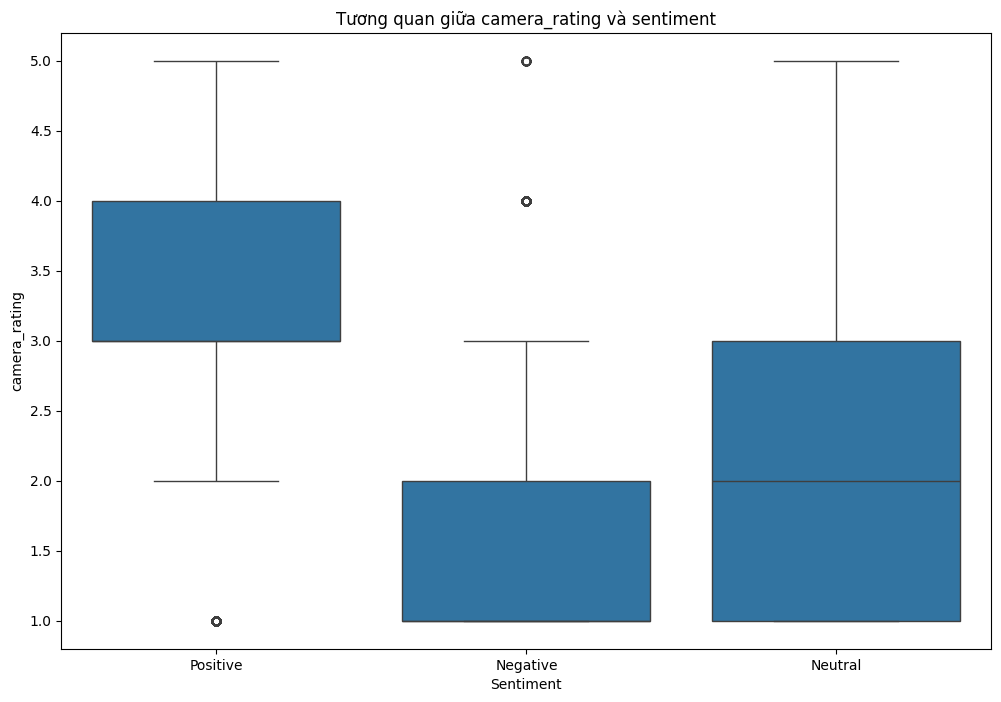

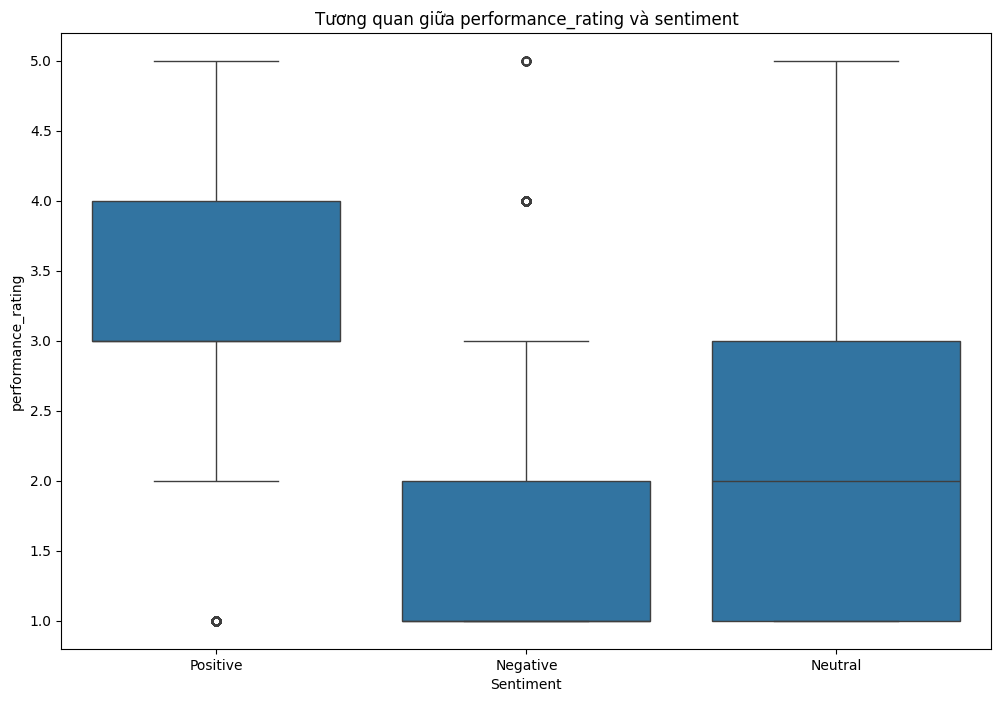

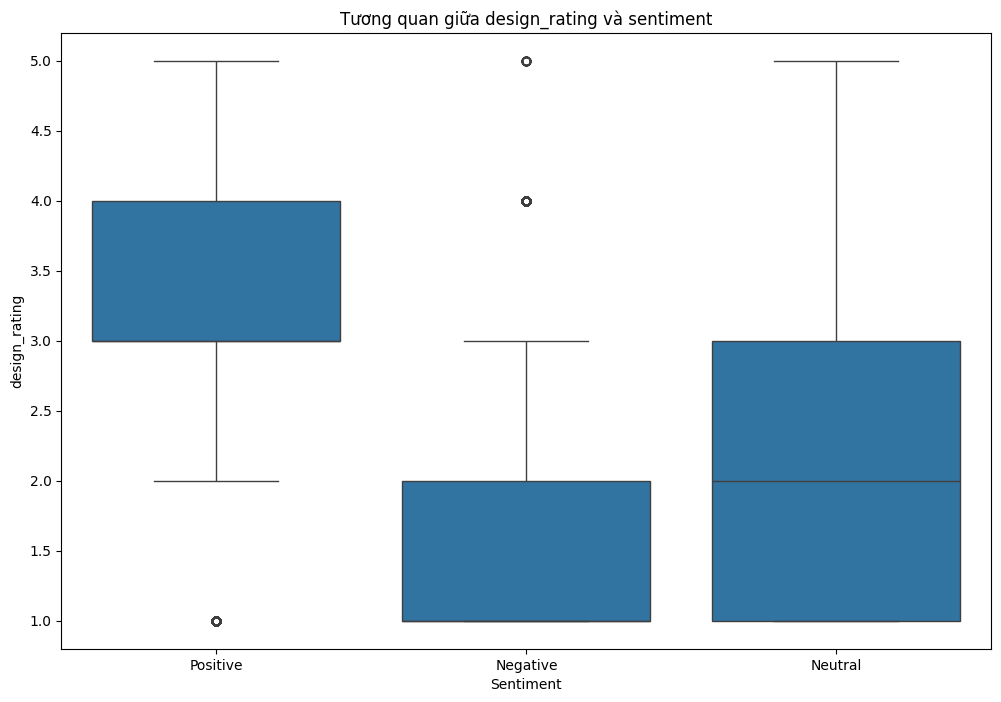

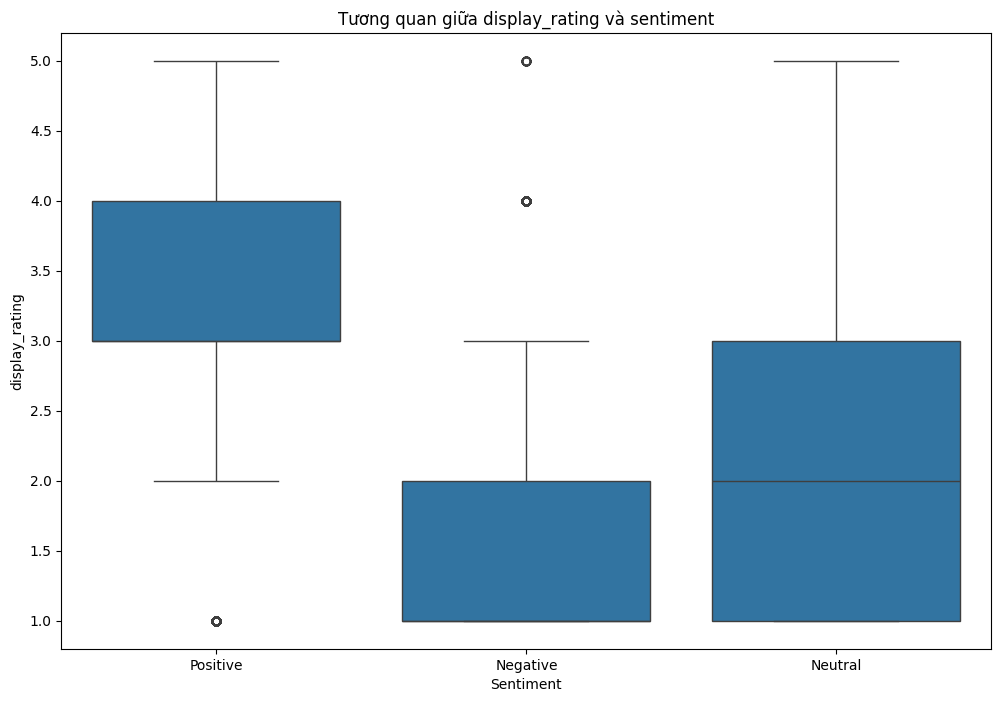

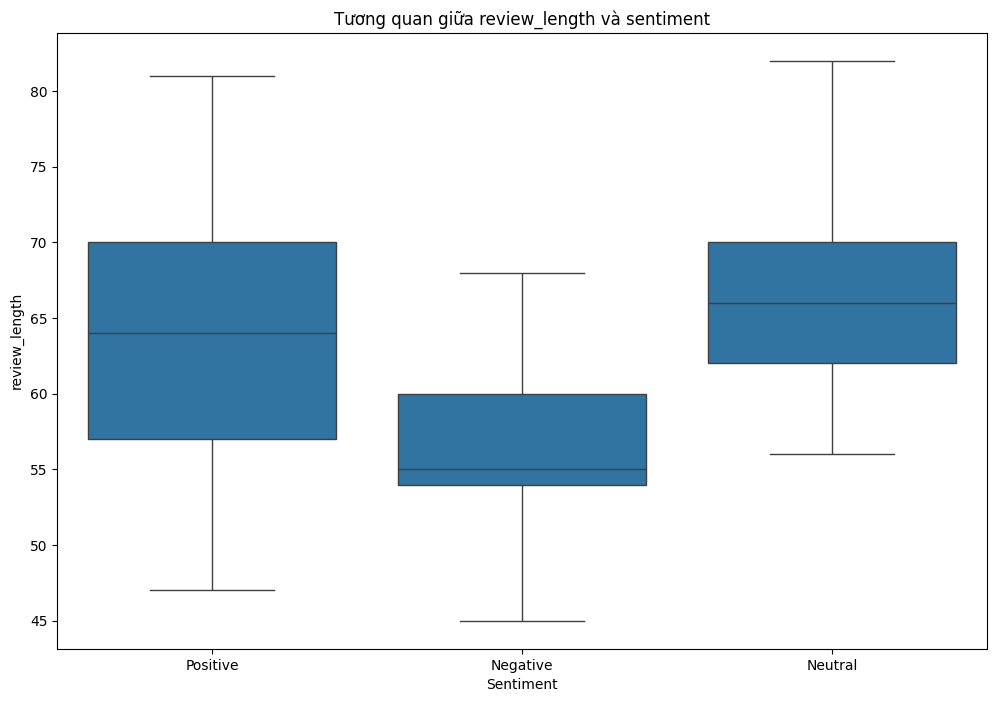

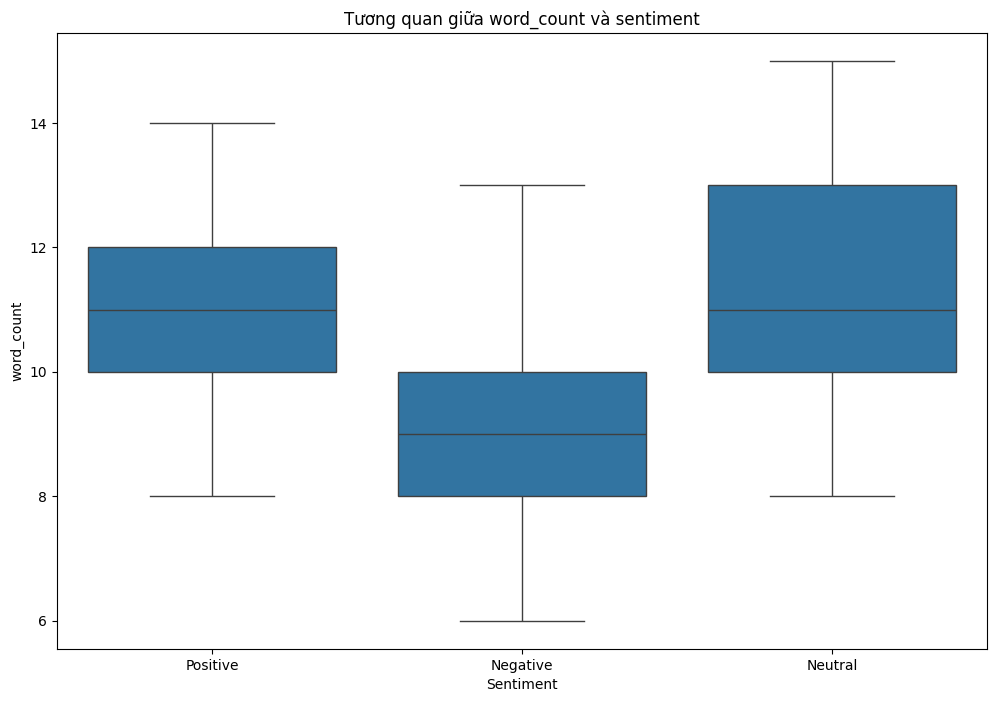

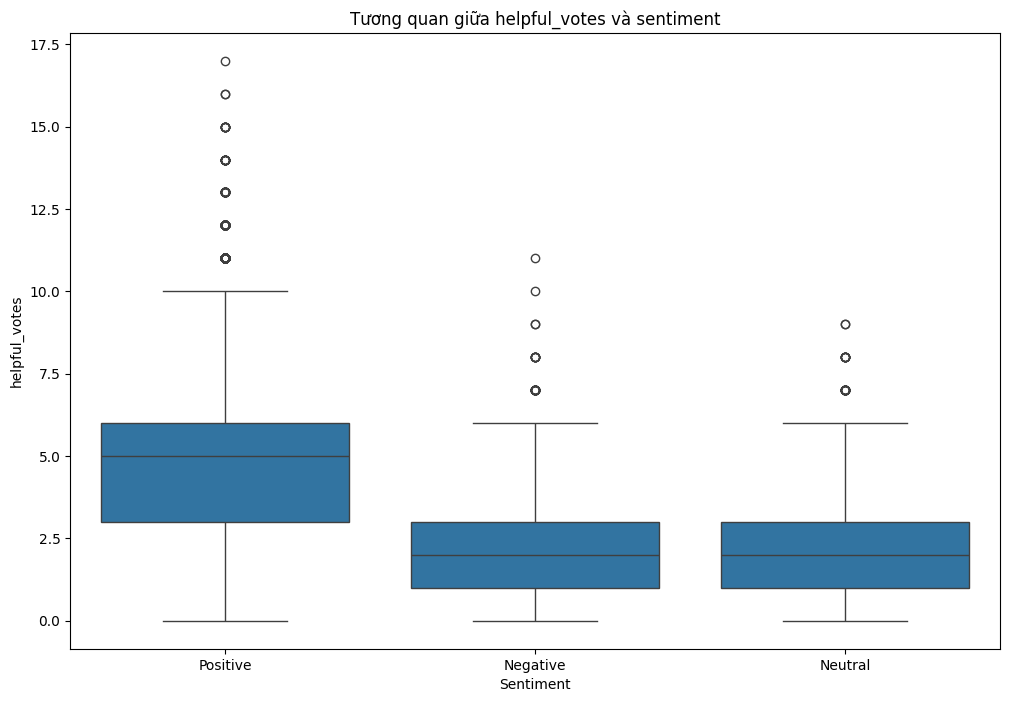

In [ ]:
target = "sentiment"
num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

if target in num_features:
    num_features.remove(target)

for col in num_features:
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"Tương quan giữa {col} và {target}")
    plt.xlabel("Sentiment")
    plt.ylabel(col)
    plt.show()

### 4.3. Xóa cột số không cần thiết

In [ ]:
df=df.drop(columns=['age', 'exchange_rate_to_usd'])

### 4.4. Trực quan các thuộc tính phân loại

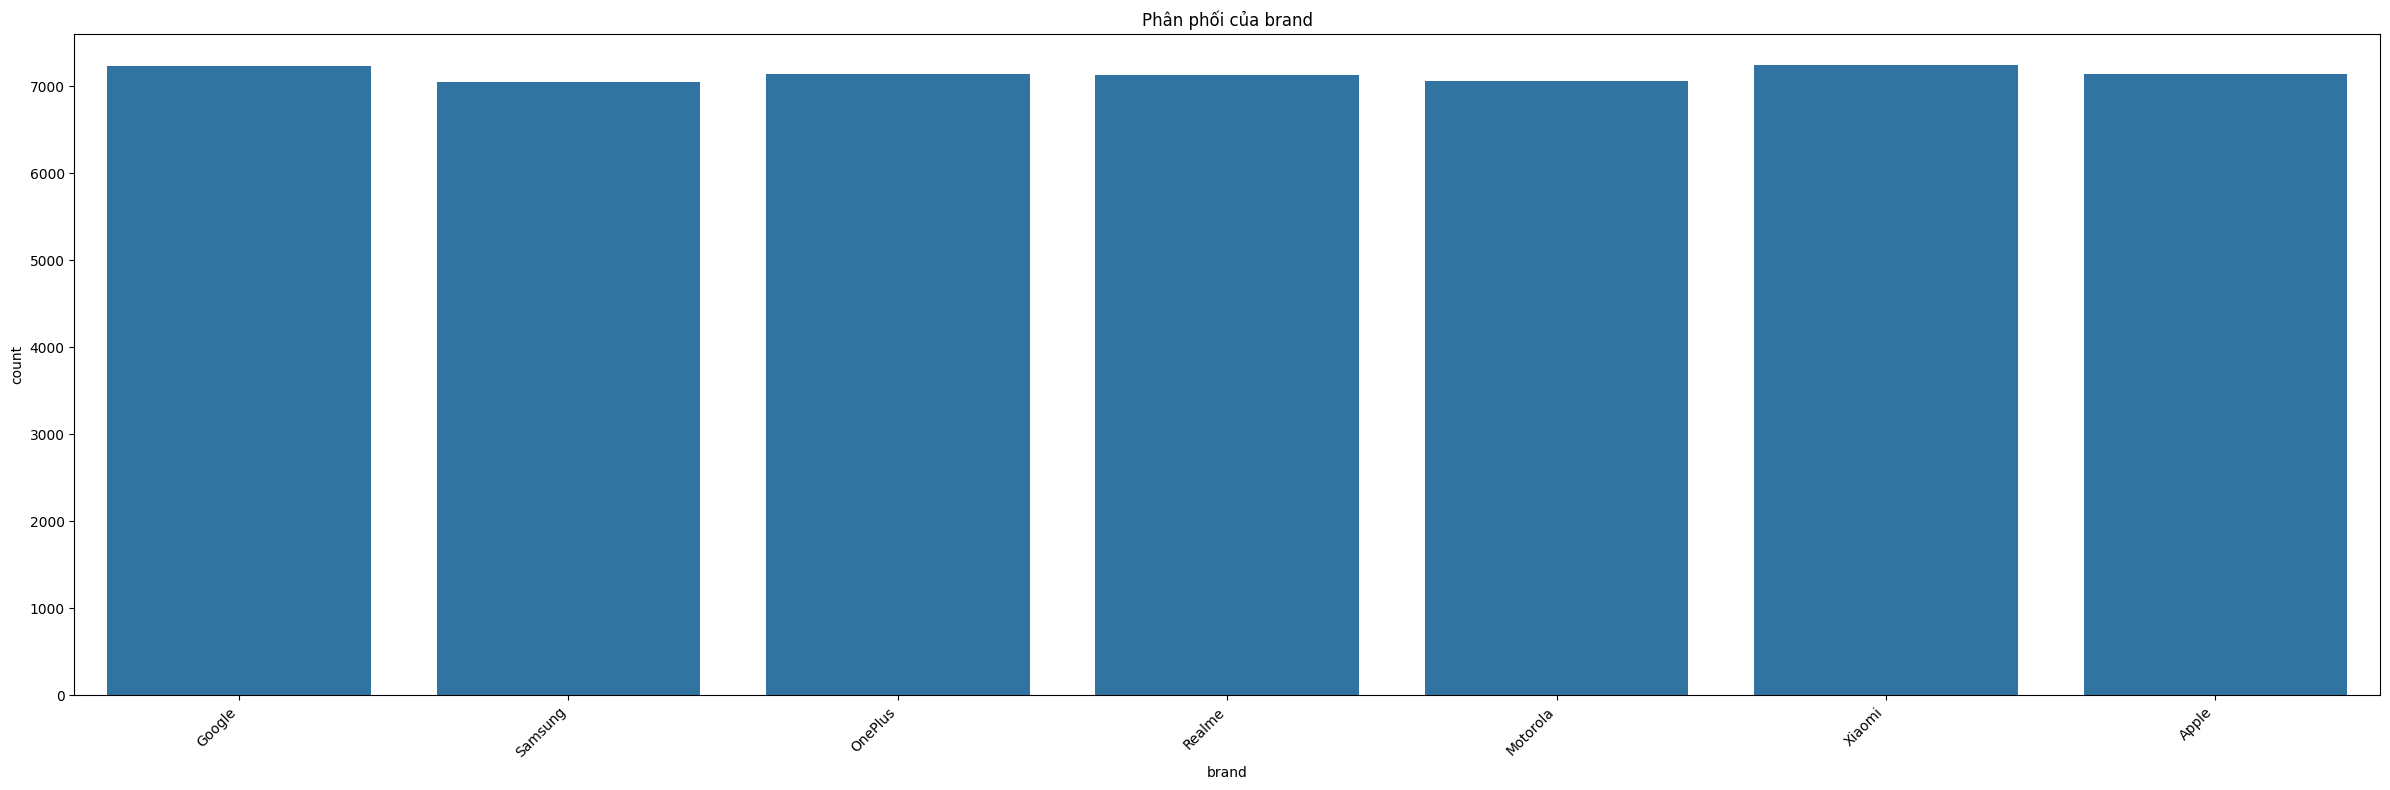

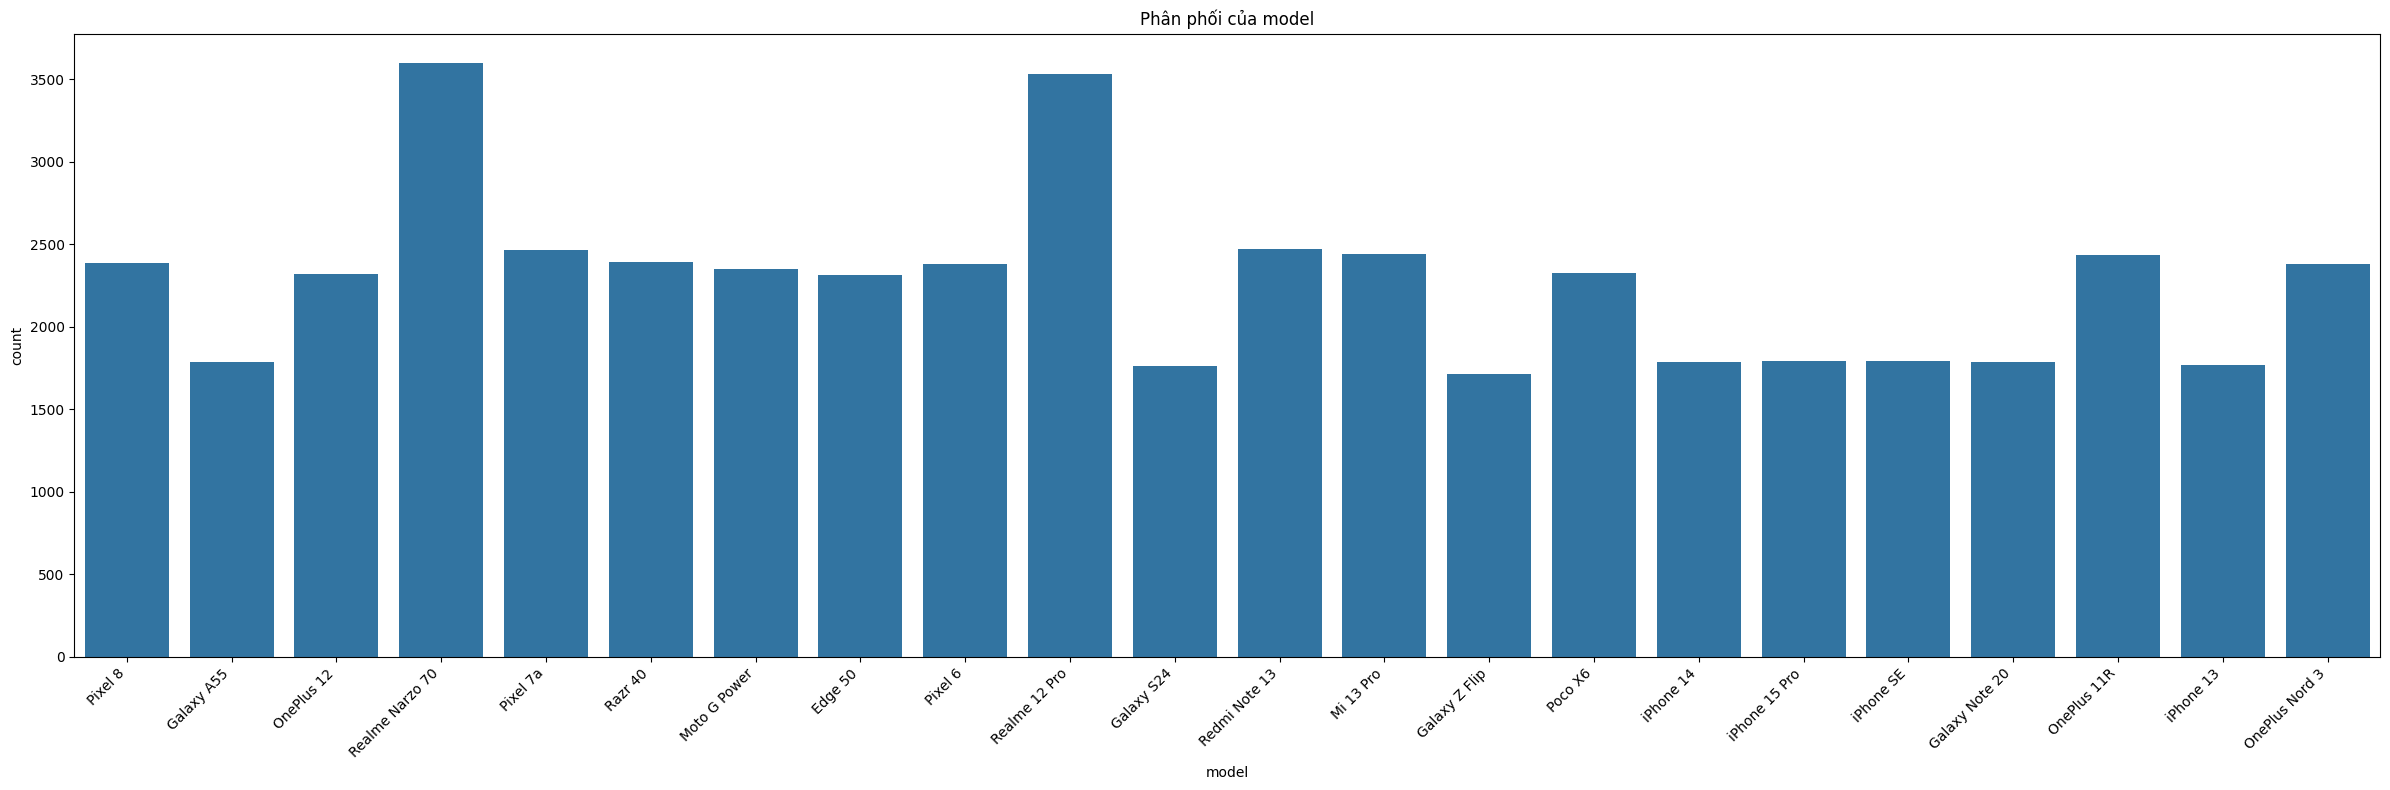

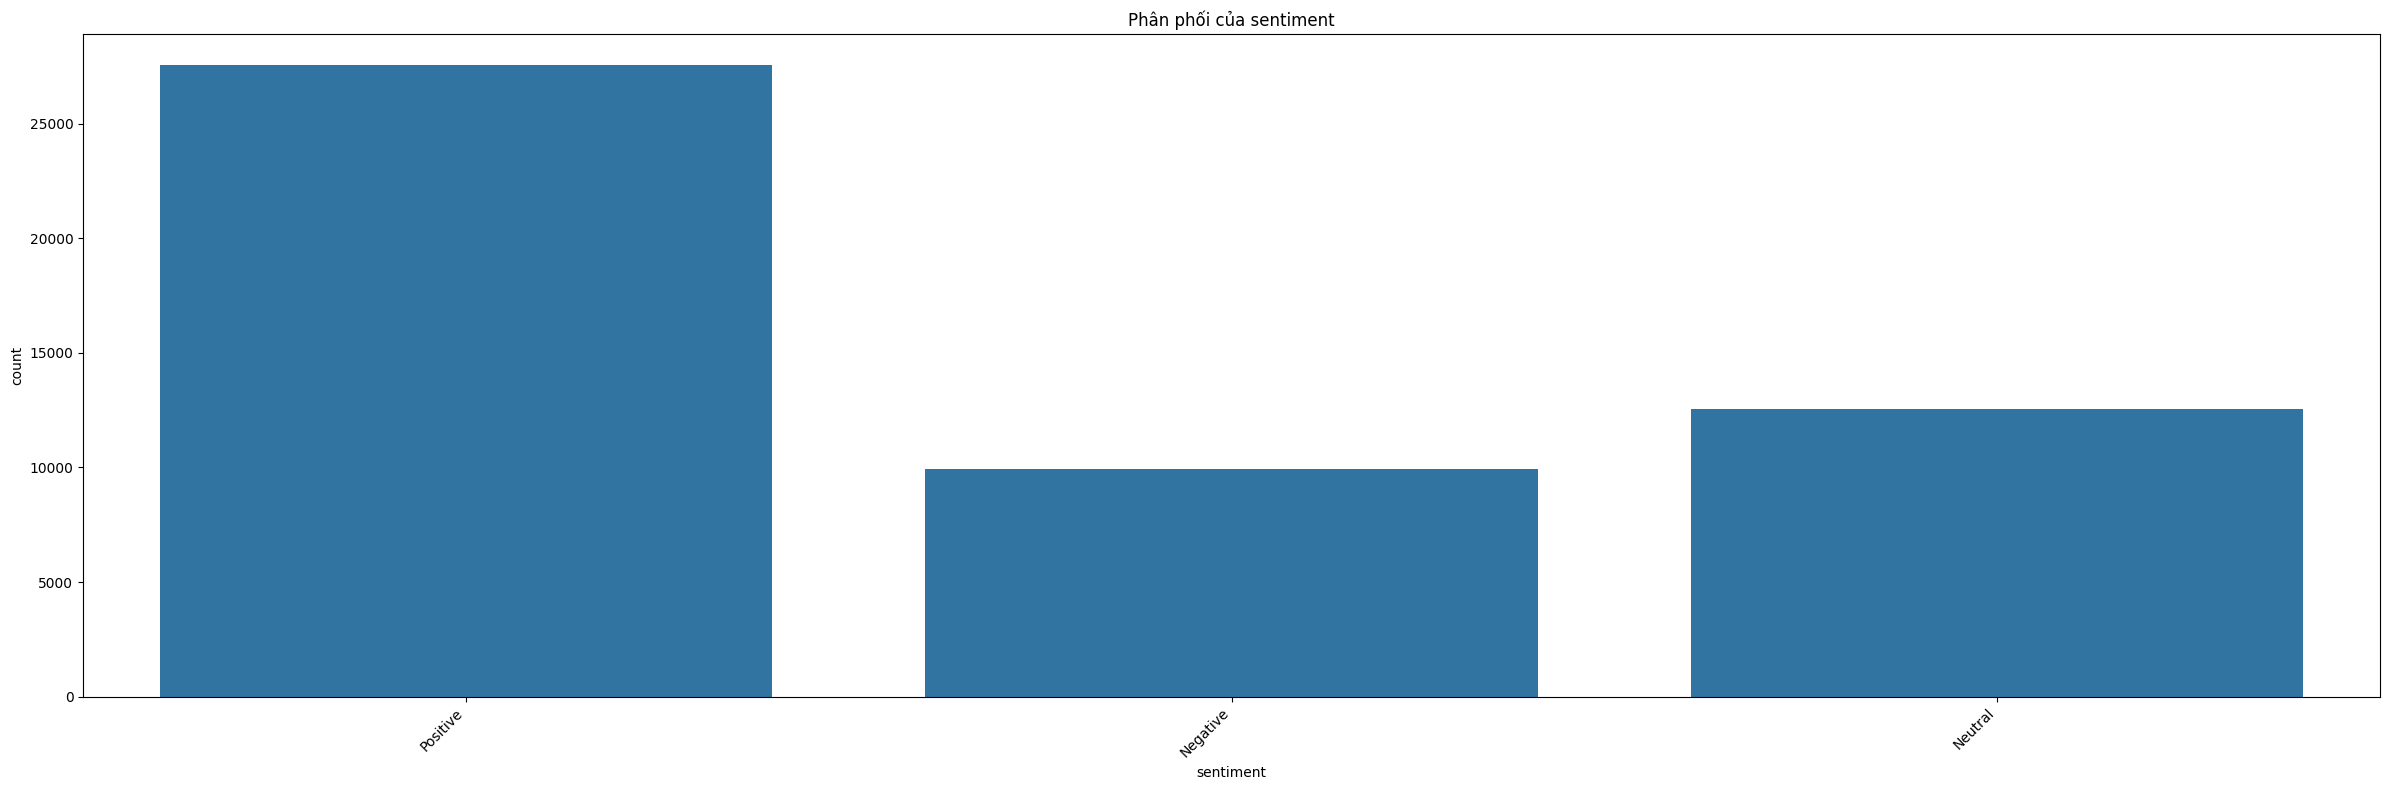

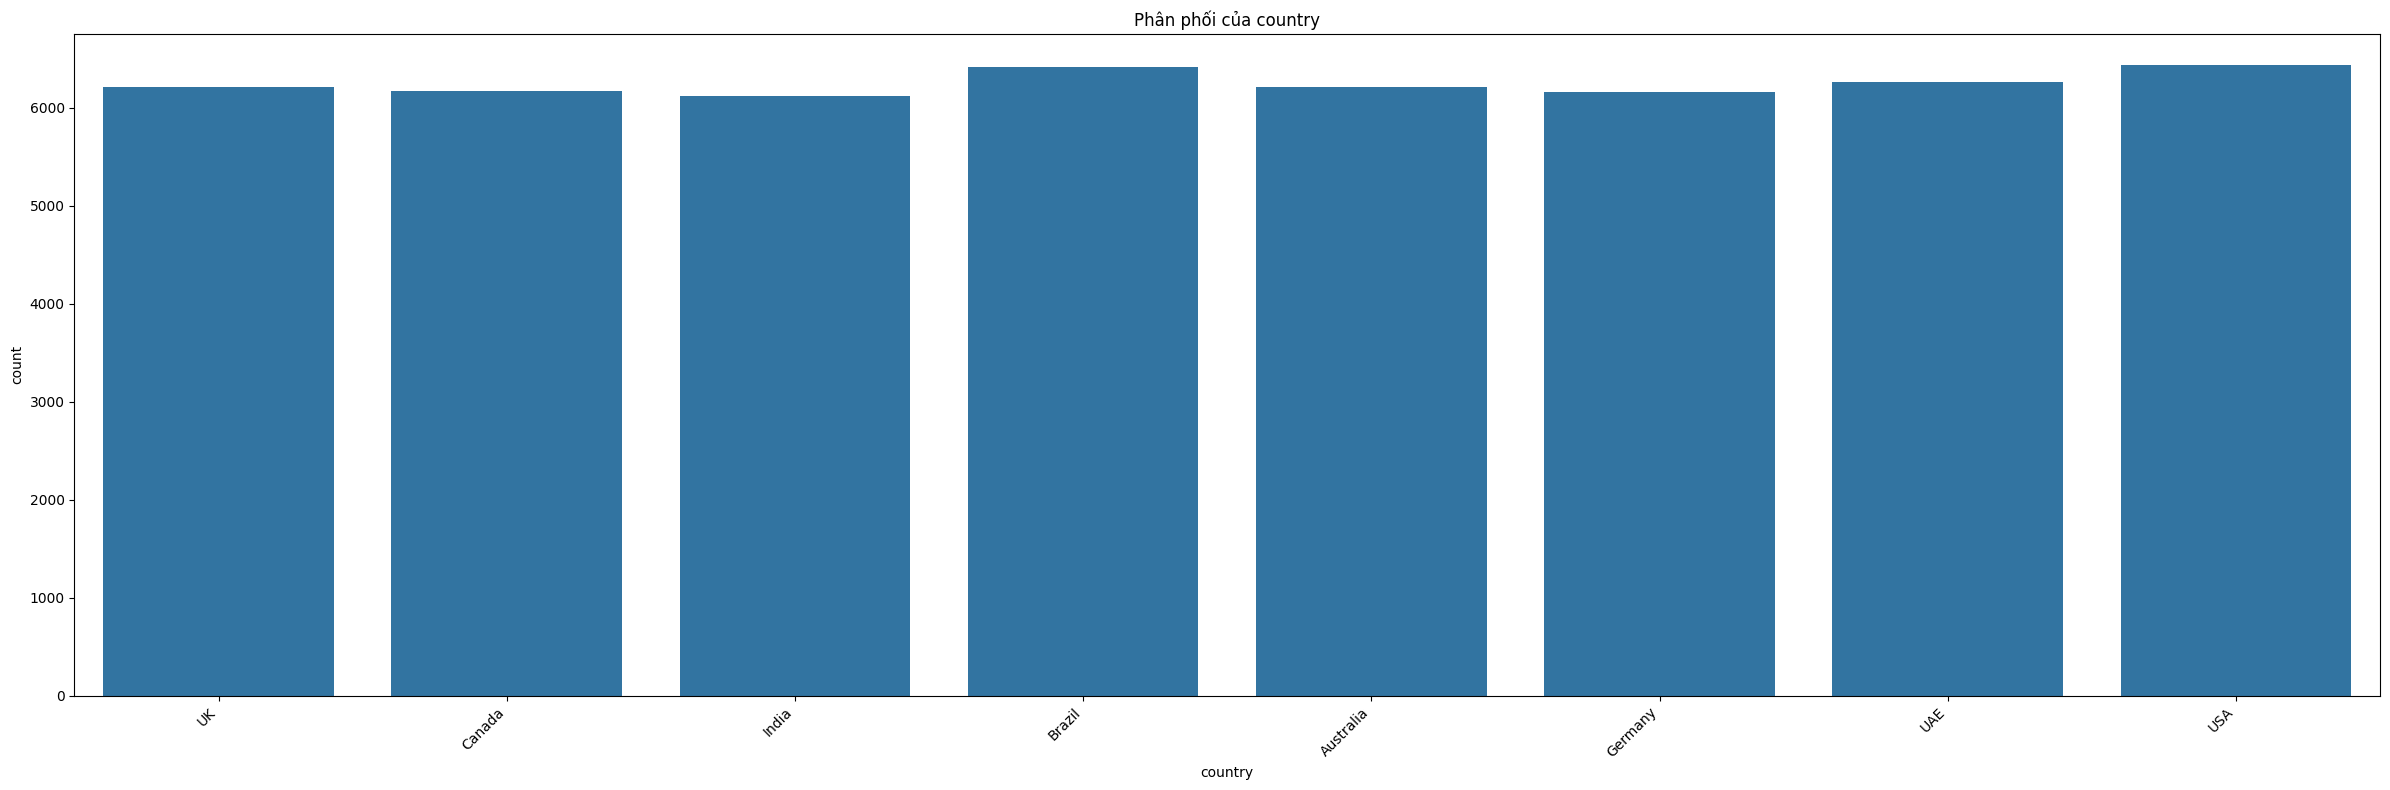

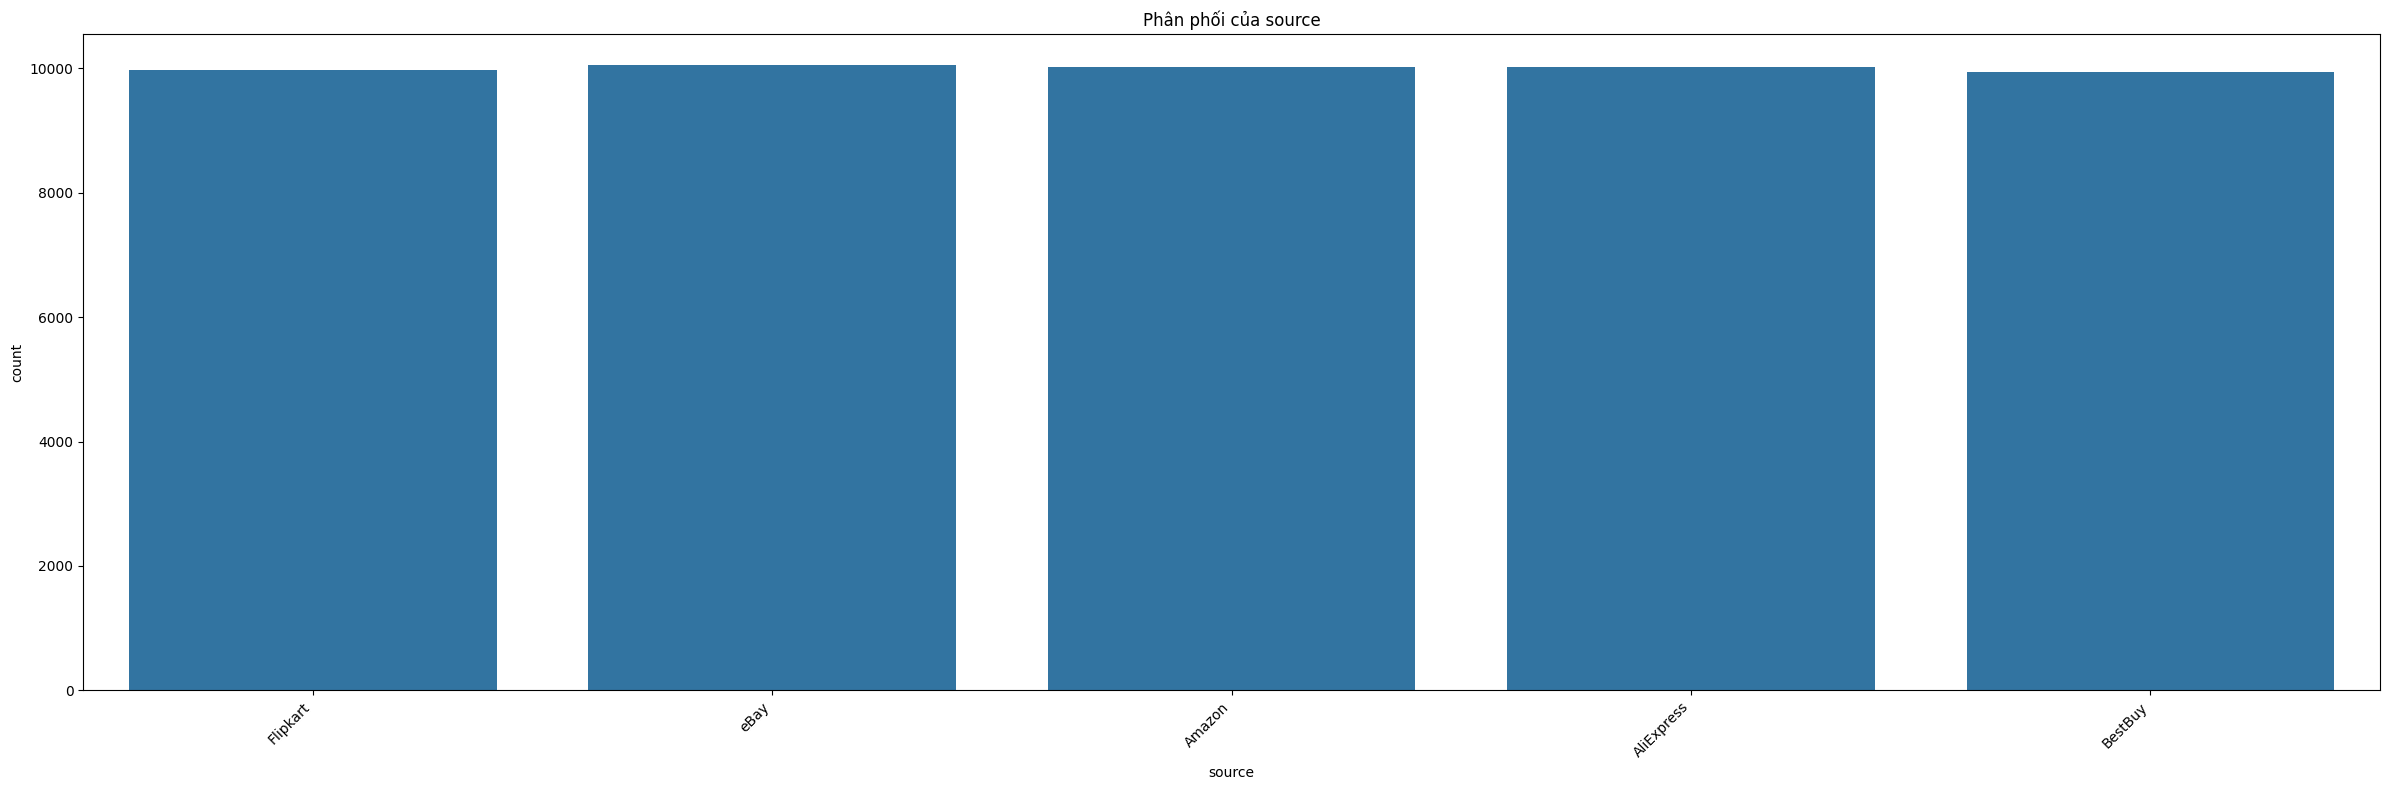

In [ ]:
cat_features = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_features:
    plt.figure(figsize=(24,8))
    sns.countplot(data=df, x=col)
    plt.title(f"Phân phối của {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

###4.5. Phân tích tương quan các thuộc tính phân loại biến mục **tiêu**

Các cột phân loại cần vẽ: ['brand', 'model', 'country', 'source']


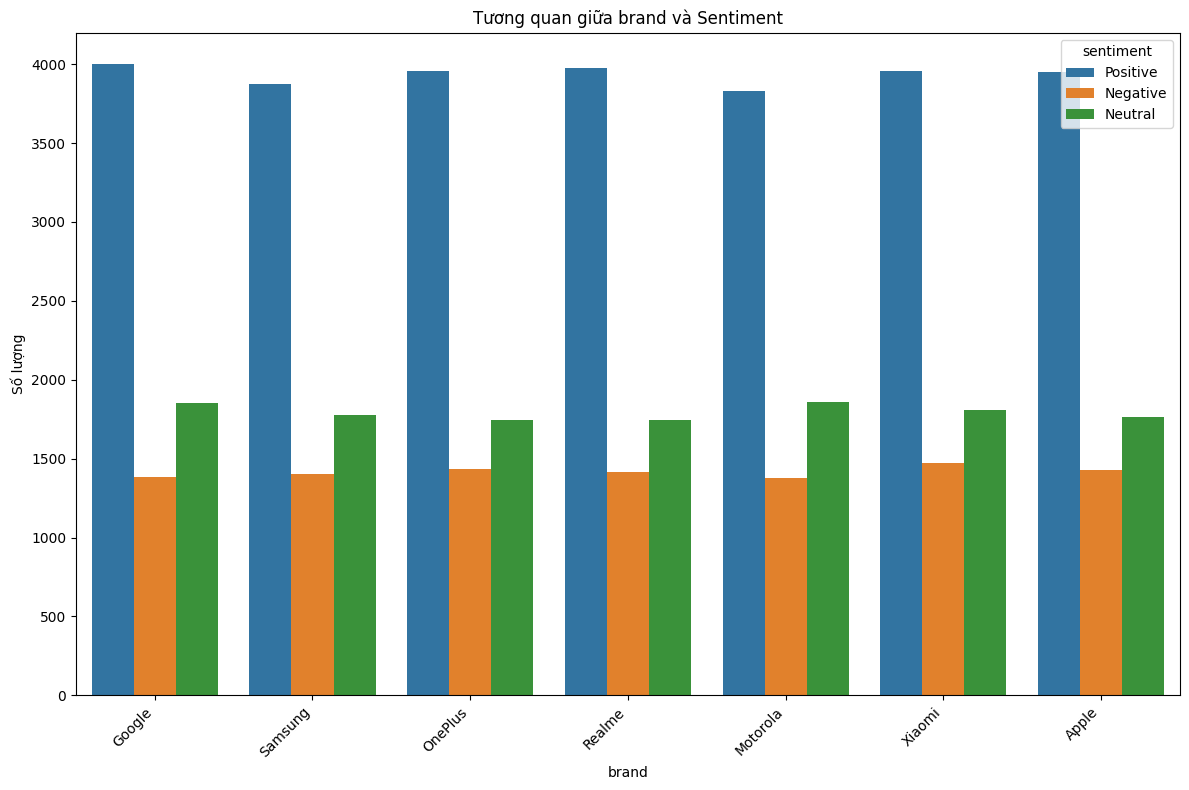

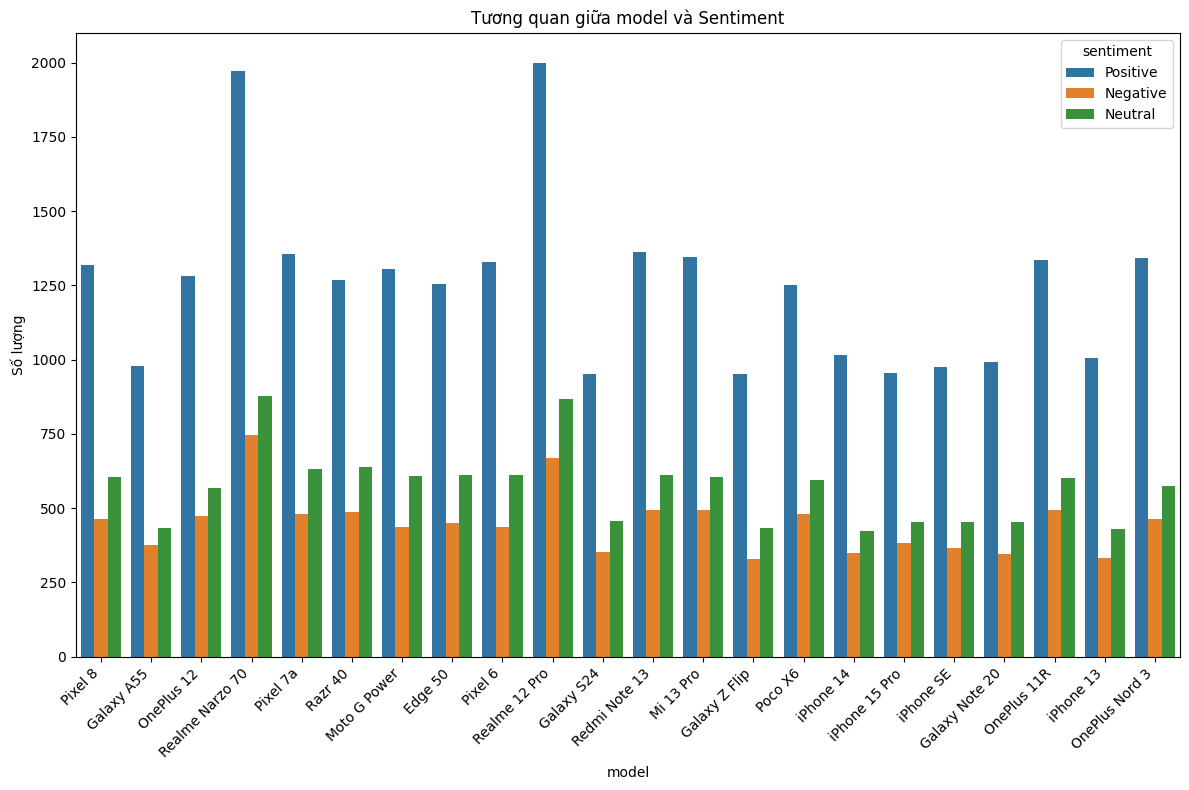

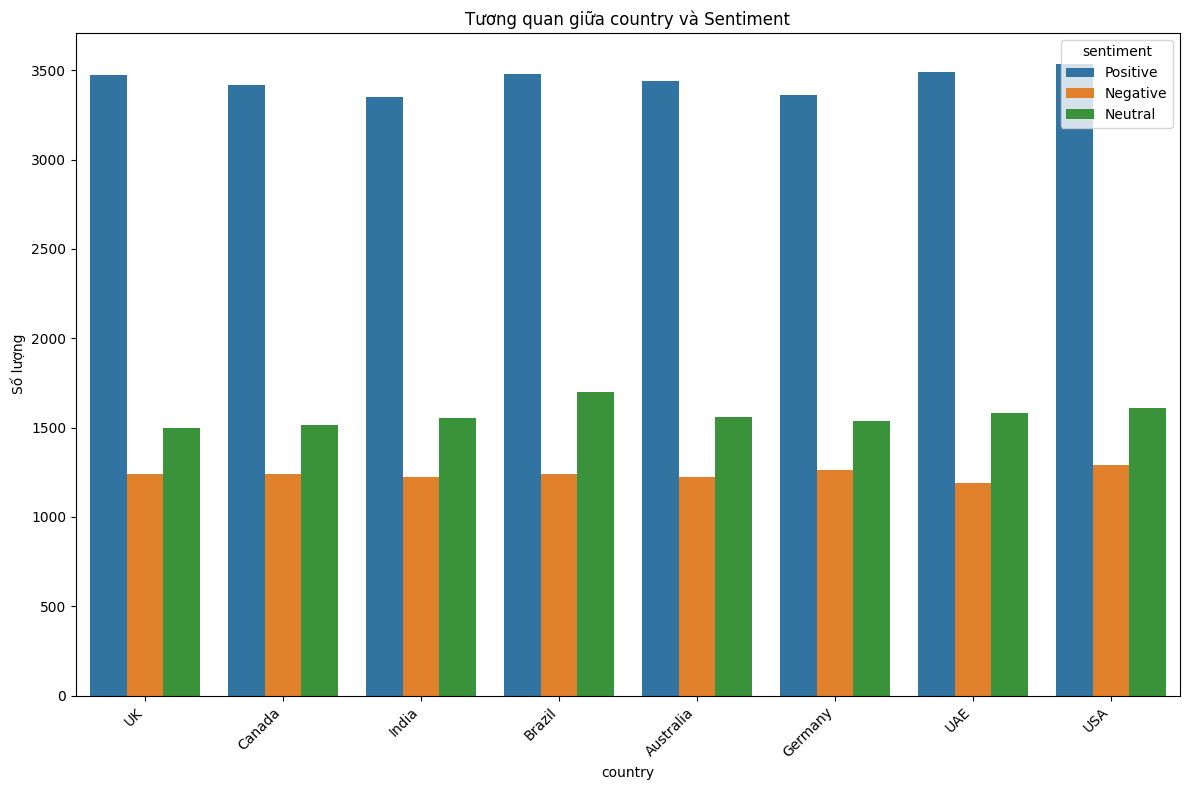

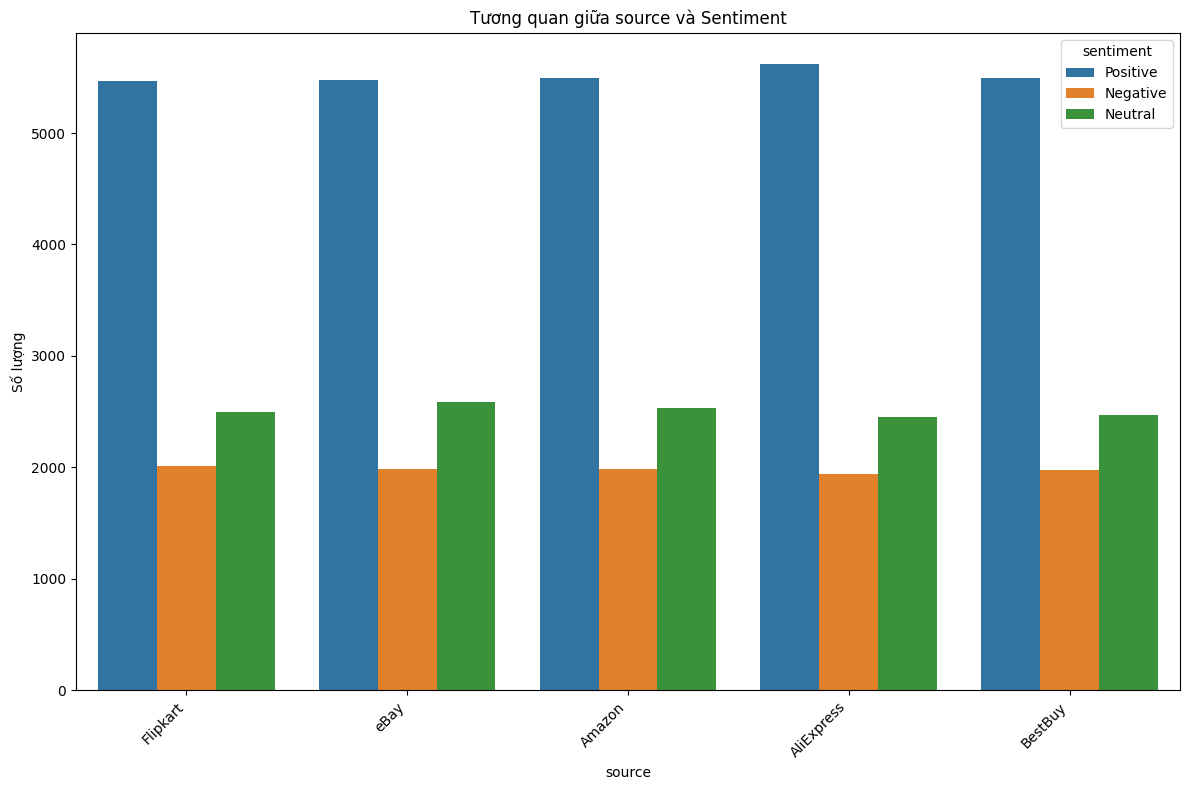

In [ ]:
target = "sentiment"
cat_features = df.select_dtypes(include=["object"]).columns.to_list()

if target in cat_features:
    cat_features.remove(target)

print("Các cột phân loại cần vẽ:", cat_features)

for col in cat_features:
    plt.figure(figsize=(12, 8))
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f"Tương quan giữa {col} và Sentiment")
    plt.xlabel(col)
    plt.ylabel("Số lượng")
    plt.legend(title="sentiment")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 2024 to 14565
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   brand                50000 non-null  object        
 1   model                50000 non-null  object        
 2   price_usd            50000 non-null  float64       
 3   rating               50000 non-null  int64         
 4   sentiment            50000 non-null  object        
 5   country              50000 non-null  object        
 6   review_date          50000 non-null  datetime64[ns]
 7   verified_purchase    50000 non-null  bool          
 8   battery_life_rating  50000 non-null  int64         
 9   camera_rating        50000 non-null  int64         
 10  performance_rating   50000 non-null  int64         
 11  design_rating        50000 non-null  int64         
 12  display_rating       50000 non-null  int64         
 13  review_length        50000 non-nu


# 5. Xử lý missing

In [ ]:
df = df.fillna(df.select_dtypes(include=['number']).median())

df = df.apply(lambda x: x.fillna(x.mode()[0]) if x.dtype == 'object' else x)

df = df.drop_duplicates()

#6. Clip Outlier

In [ ]:
cols_to_clip = ['price_usd', 'review_length', 'word_count', 'helpful_votes']

for col in cols_to_clip:
    p1, p99 = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(p1, p99)
df.head()

,brand,model,price_usd,rating,sentiment,country,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
2024,Google,Pixel 8,823.98,4,Positive,UK,2022-10-22,True,3,4,1,4,4,47,9,8,Flipkart
34,Samsung,Galaxy A55,1071.57,4,Positive,Canada,2022-10-22,True,4,5,5,4,2,64,12,4,Flipkart
1299,OnePlus,OnePlus 12,891.57,5,Positive,India,2022-10-22,True,4,4,5,4,5,71,12,7,eBay
20048,Realme,Realme Narzo 70,531.89,2,Negative,UK,2022-10-22,False,3,1,2,3,1,62,9,1,Amazon
39785,Google,Pixel 7a,720.63,5,Positive,India,2022-10-22,False,5,5,5,5,4,78,14,9,Flipkart


#7. MinMax Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['price_usd', 'review_length', 'word_count', 'helpful_votes']
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df.head()

,brand,model,price_usd,rating,sentiment,country,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,word_count,helpful_votes,source
2024,Google,Pixel 8,0.498680,4,Positive,UK,2022-10-22,True,3,4,1,4,4,0.028571,0.375,0.8,Flipkart
34,Samsung,Galaxy A55,0.698002,4,Positive,Canada,2022-10-22,True,4,5,5,4,2,0.514286,0.750,0.4,Flipkart
1299,OnePlus,OnePlus 12,0.553093,5,Positive,India,2022-10-22,True,4,4,5,4,5,0.714286,0.750,0.7,eBay
20048,Realme,Realme Narzo 70,0.263533,2,Negative,UK,2022-10-22,False,3,1,2,3,1,0.457143,0.375,0.1,Amazon
39785,Google,Pixel 7a,0.415478,5,Positive,India,2022-10-22,False,5,5,5,5,4,0.914286,1.000,0.9,Flipkart


#8. Feature Engineering (Lag, Rolling, Calendar, Interaction)

In [ ]:
lags = [1, 7, 14, 28]
windows = [7, 14, 28]

### 8.1. Lag


In [ ]:
for lag in lags:
    df[f"brand_rating_lag_{lag}"] = df.groupby("brand")["rating"].shift(lag)

### 8.2. Rolling

In [ ]:
for w in windows:
    group = df.groupby("brand")["rating"].shift(1)

    df[f"brand_rating_roll_mean_{w}"] = group.rolling(window=w, min_periods=1).mean().values
    df[f"brand_rating_roll_std_{w}"]  = group.rolling(window=w, min_periods=1).std().values
    df[f"brand_rating_roll_max_{w}"]  = group.rolling(window=w, min_periods=1).max().values
    df[f"brand_rating_roll_min_{w}"]  = group.rolling(window=w, min_periods=1).min().values

### 8.3. Calendar

In [ ]:
df["dow"] = df["review_date"].dt.dayofweek
df["week"] = df["review_date"].dt.isocalendar().week.astype(int)
df["month"] = df["review_date"].dt.month
df["quarter"] = df["review_date"].dt.quarter
df["is_weekend"] = (df["dow"].isin([5, 6])).astype(int)
df["is_month_end"] = df["review_date"].dt.is_month_end.astype(int)

### 8.4. Interaction

In [ ]:
# Tương tác giữa các điểm số thành phần
df['avg_specs_rating'] = df[['battery_life_rating', 'camera_rating', 'performance_rating', 'display_rating']].mean(axis=1)

# Tương tác giữa Rating và Price
df['p_p_ratio'] = df['rating'] / (df['price_usd'] + 0.1)

#Tương tác giữa số lượt Vote và Rating
df['reputation_score'] = df['helpful_votes'] * df['rating']

#9. Xử lý One-hot và LabelEncoder

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

cols_onehot = ['model' ,'verified_purchase', 'country', 'source']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[cols_onehot])

encoded_cols = encoder.get_feature_names_out(cols_onehot)
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols)

df_final = pd.concat([df.drop(columns=['model','sentiment','verified_purchase', 'country', 'source']), df_encoded], axis=1)
df=df_final
df.head()


,brand,price_usd,rating,review_date,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,review_length,...,country_Germany,country_India,country_UAE,country_UK,country_USA,source_AliExpress,source_Amazon,source_BestBuy,source_Flipkart,source_eBay
2024,Google,0.498680,4,2022-10-22,3,4,1,4,4,0.028571,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
34,Samsung,0.698002,4,2022-10-22,4,5,5,4,2,0.514286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1299,OnePlus,0.553093,5,2022-10-22,4,4,5,4,5,0.714286,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
20048,Realme,0.263533,2,2022-10-22,3,1,2,3,1,0.457143,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
39785,Google,0.415478,5,2022-10-22,5,5,5,5,4,0.914286,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
df = df.dropna()

# 10. Block CV theo horizon 14

In [ ]:
import numpy as np
import pandas as pd

def brand_block_cv(df_brand, n_splits=5, horizon_days=14, holdout_days=14):

    df_brand = df_brand.sort_values('review_date').reset_index(drop=True)
    dates = df_brand['review_date']

    effective_latest_date = dates.max() - pd.Timedelta(days=holdout_days)

    splits = []

    for i in range(n_splits):

        test_end = effective_latest_date - pd.Timedelta(days=i * horizon_days)
        test_start = test_end - pd.Timedelta(days=horizon_days)

        test_idx = df_brand[(dates > test_start) & (dates <= test_end)].index.values
        train_idx = df_brand[dates <= test_start].index.values

        if len(train_idx) > 50 and len(test_idx) > 0:
            splits.append((train_idx, test_idx))

    return splits[::-1]

# 11. Thực hiện train model theo từng brand

### 11.1. Dùng bộ tham số cố định

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error

models_brand_rf_fixed = {}
metrics_brand_rf_fixed = {}
preds_list_rf_fixed = []

target_col = "sentiment_encoded"
holdout_days = 14

for brand_name in df["brand"].unique():
    df_b = df[df["brand"] == brand_name].sort_values("review_date").reset_index(drop=True)

    if len(df_b) < 100:
        continue

    test_actual_cutoff = df_b["review_date"].max() - pd.Timedelta(days=holdout_days)

    df_cv = df_b[df_b["review_date"] < test_actual_cutoff].reset_index(drop=True)
    df_holdout = df_b[df_b["review_date"] >= test_actual_cutoff].reset_index(drop=True)

    if len(df_holdout) == 0 or len(df_cv) < 50:
        continue

    features = [c for c in df_b.columns if c not in ["review_date", target_col, "brand", "model"]]

    X_cv, y_cv = df_cv[features], df_cv[target_col]
    X_holdout, y_holdout = df_holdout[features], df_holdout[target_col]

    splits = brand_block_cv(df_cv, n_splits=5, horizon_days=14)

    acc_folds_rf_fixed = []

    for train_idx, val_idx in splits:
        X_train, X_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
        y_train, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        model = RandomForestClassifier(
            n_estimators=800,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        acc_folds_rf_fixed.append(accuracy_score(y_val, y_pred))

    print(f"Brand={brand_name:<10} | AVG_CV_ACC={np.mean(acc_folds_rf_fixed):.3f}")

    # 5. Huấn luyện FINAL MODEL
    final_cutoff = df_cv["review_date"].max() - pd.Timedelta(days=14)
    X_tr = X_cv[df_cv["review_date"] < final_cutoff]
    y_tr = y_cv[df_cv["review_date"] < final_cutoff]

    n_train_samples_rf_fixed = len(X_tr)

    # FINAL MODEL
    final_model_rf_fixed = RandomForestClassifier(
        n_estimators=1000,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
    final_model_rf_fixed.fit(X_tr, y_tr)

    # Dự báo trên tập Hold-out
    y_holdout_pred_rf_fixed = final_model_rf_fixed.predict(X_holdout)

    # Lưu kết quả
    models_brand_rf_fixed[brand_name] = final_model_rf_fixed

    preds_list_rf_fixed.append(pd.DataFrame({
        "Date": df_holdout["review_date"],
        "Actual": y_holdout.values,
        "Predicted": y_holdout_pred_rf_fixed,
        "Brand": brand_name
    }))

    # Tính toán các chỉ số phân loại
    acc_rf_fixed = accuracy_score(y_holdout, y_holdout_pred_rf_fixed)
    prec_rf_fixed = precision_score(y_holdout, y_holdout_pred_rf_fixed, average='weighted', zero_division=0)
    rec_rf_fixed = recall_score(y_holdout, y_holdout_pred_rf_fixed, average='weighted', zero_division=0)
    f1_rf_fixed = f1_score(y_holdout, y_holdout_pred_rf_fixed, average='weighted', zero_division=0)

    metrics_brand_rf_fixed[brand_name] = {
        "Accuracy": acc_rf_fixed,
        "Precision": prec_rf_fixed,
        "Recall": rec_rf_fixed,
        "F1-Score": f1_rf_fixed,
        "n_train": n_train_samples_rf_fixed,
        "n_test": len(df_holdout)
    }

# Tổng hợp metrics
metrics_df_rf_fixed = pd.DataFrame.from_dict(metrics_brand_rf_fixed, orient="index")

print("\n KẾT QUẢ TRAIN FINAL MODEL")
print(metrics_df_rf_fixed.round(4))

all_preds_final_rf_fixed = pd.concat(preds_list_rf_fixed)

Brand=Samsung    | AVG_CV_ACC=0.838
Brand=Google     | AVG_CV_ACC=0.840
Brand=Xiaomi     | AVG_CV_ACC=0.881
Brand=Motorola   | AVG_CV_ACC=0.879
Brand=Apple      | AVG_CV_ACC=0.876
Brand=Realme     | AVG_CV_ACC=0.881
Brand=OnePlus    | AVG_CV_ACC=0.845

 KẾT QUẢ TRAIN FINAL MODEL
          Accuracy  Precision  Recall  F1-Score  n_train  n_test
Samsung     0.9101     0.9117  0.9101    0.9106     6852      89
Google      0.8778     0.8923  0.8778    0.8741     7012      90
Xiaomi      0.8929     0.8985  0.8929    0.8945     7026      84
Motorola    0.8800     0.8842  0.8800    0.8816     6828     100
Apple       0.9320     0.9348  0.9320    0.9318     6921     103
Realme      0.8041     0.8026  0.8041    0.8032     6896      97
OnePlus     0.8817     0.8835  0.8817    0.8790     6905      93


### 11.2. Dò tuning chọn bộ tham số tốt nhất

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os

models_brand = {}
metrics_brand = {}
preds_list = []

target_col = "sentiment_encoded"
holdout_days = 14

param_grid_rf = {
    'n_estimators': [500, 800, 1000],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

for brand_name in df["brand"].unique():
    df_b = df[df["brand"] == brand_name].sort_values("review_date").reset_index(drop=True)

    if len(df_b) < 100:
        continue

    test_actual_cutoff = df_b["review_date"].max() - pd.Timedelta(days=holdout_days)
    df_cv = df_b[df_b["review_date"] < test_actual_cutoff].reset_index(drop=True)
    df_holdout = df_b[df_b["review_date"] >= test_actual_cutoff].reset_index(drop=True)

    if len(df_holdout) == 0 or len(df_cv) < 50:
        continue

    features = [c for c in df_b.columns if c not in ["review_date", target_col, "brand", "model"]]
    X_cv, y_cv = df_cv[features], df_cv[target_col]
    X_holdout, y_holdout = df_holdout[features], df_holdout[target_col]

    param_list = list(ParameterSampler(param_grid_rf, n_iter=8, random_state=42))
    splits = list(brand_block_cv(df_cv, n_splits=5, horizon_days=14))

    best_score = -1
    best_params = {}

    for p in param_list:
        fold_scores = []
        for train_idx, val_idx in splits:
            X_train, X_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
            y_train, y_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

            model_tmp = RandomForestClassifier(**p, n_jobs=-1, random_state=42)
            model_tmp.fit(X_train, y_train)

            y_pred = model_tmp.predict(X_val)
            fold_scores.append(f1_score(y_val, y_pred, average='weighted'))

        avg_score = np.mean(fold_scores)
        if avg_score > best_score:
            best_score = avg_score
            best_params = p

    print(f"Tham số tốt nhất cho {brand_name}: {best_params}")

    # Huấn luyện Final model
    final_model = RandomForestClassifier(
        **best_params,
        n_jobs=-1,
        random_state=42
    )

    final_model.fit(X_cv, y_cv)
    y_holdout_pred = final_model.predict(X_holdout)

    # 6. Lưu kết quả
    models_brand[brand_name] = final_model
    preds_list.append(pd.DataFrame({
        "Date": df_holdout["review_date"],
        "Actual": y_holdout.values,
        "Predicted": y_holdout_pred,
        "Brand": brand_name
    }))

    metrics_brand[brand_name] = {
        "Accuracy": accuracy_score(y_holdout, y_holdout_pred),
        "Precision": precision_score(y_holdout, y_holdout_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_holdout, y_holdout_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_holdout, y_holdout_pred, average='weighted', zero_division=0),
        "n_train": len(X_cv),
        "n_test": len(df_holdout),
        "Best_Params": str(best_params)
    }

# Tổng hợp kết quả
metrics_df = pd.DataFrame.from_dict(metrics_brand, orient="index")
print("\nKẾT QUẢ CUỐI CÙNG SAU KHI DÒ THAM SỐ RANDOM FOREST TỪNG BRAND\n")
print(metrics_df[['Accuracy', 'F1-Score','Precision','Recall', 'n_train', 'n_test']].round(4))

all_preds_final = pd.concat(preds_list)

Tham số tốt nhất cho Samsung: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Tham số tốt nhất cho Google: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Tham số tốt nhất cho Xiaomi: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Tham số tốt nhất cho Motorola: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Tham số tốt nhất cho Apple: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Tham số tốt nhất cho Realme: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Tham số tốt nhất cho OnePlus: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

KẾT QUẢ CUỐI CÙNG S

# 12. Consfusion Matrix

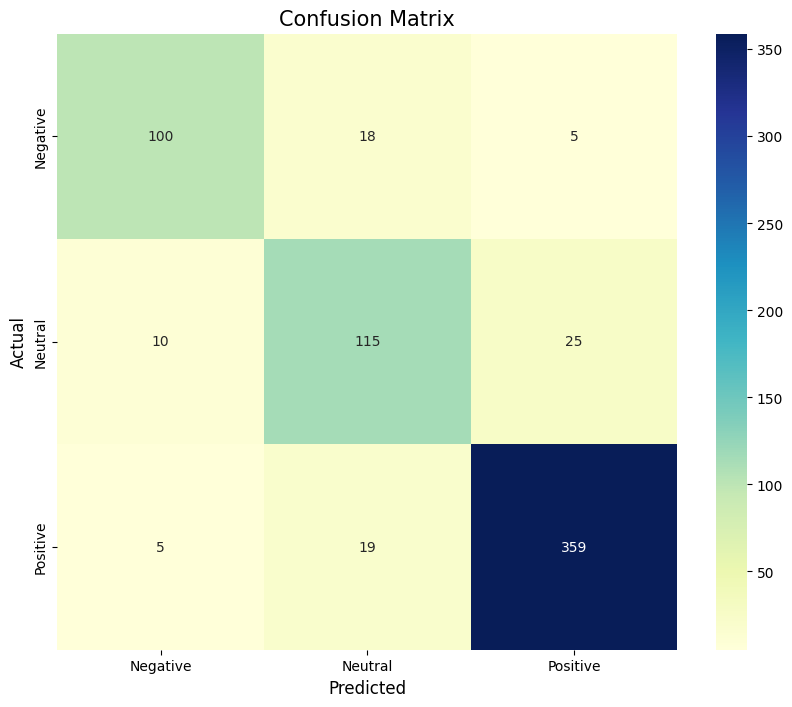

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Mapping chuẩn: 0: Negative, 1: Neutral, 2: Positive
labels = ['Negative', 'Neutral', 'Positive']

# 2. Tính ma trận cho tổng các dự báo
cm_total = confusion_matrix(all_preds_final['Actual'], all_preds_final['Predicted'])

# 3. Vẽ biểu đồ tổng
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_total,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix', fontsize=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
# Lưu plot
plot_path = f"/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/DOAN/plots/plots_RF"
os.makedirs(plot_path, exist_ok=True)
plt.savefig(os.path.join(plot_path, f"Confusion_Matrix.png"), bbox_inches='tight')
plt.show()

# 13.  Feature Importance

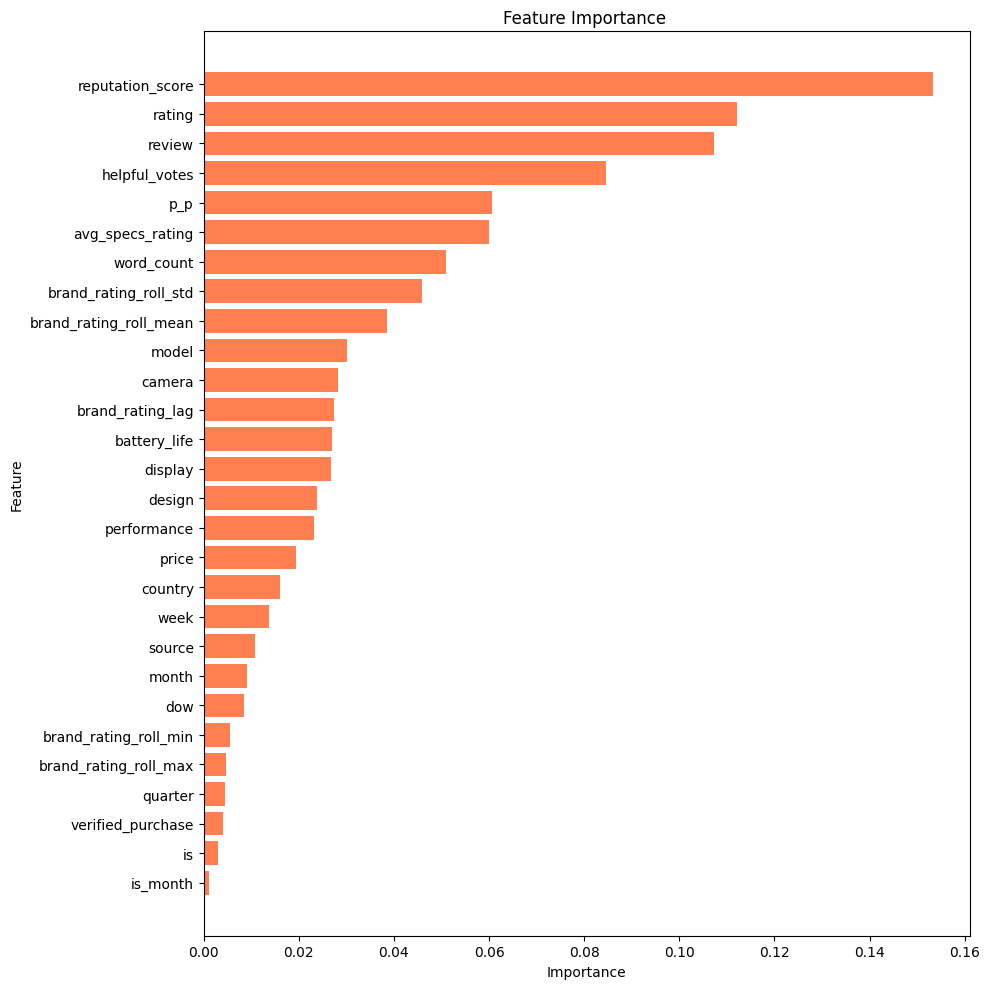

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp_df = pd.DataFrame({
    'feature': features,
    'importance': final_model.feature_importances_
})

# Gom các cột đã One - hot về cột gốc để biểu diễn
def auto_aggregate(df):
    new_rows = []
    processed_prefixes = set()

    keep_as_is = ['reputation_score', 'word_count', 'avg_specs_rating', 'helpful_votes']

    for feat in df['feature']:
        if "_" in feat and feat not in keep_as_is:
            prefix = "_".join(feat.split("_")[:-1])

            if prefix not in processed_prefixes:
                total_imp = df[df['feature'].str.startswith(prefix + "_")]['importance'].sum()
                new_rows.append({'feature': prefix, 'importance': total_imp})
                processed_prefixes.add(prefix)
        else:
            if not any(feat.startswith(p + "_") for p in processed_prefixes):
                new_rows.append({'feature': feat, 'importance': df[df['feature'] == feat]['importance'].values[0]})

    return pd.DataFrame(new_rows).sort_values(by='importance', ascending=True)

# Chạy hàm gom và vẽ
agg_df = auto_aggregate(feat_imp_df)

plt.figure(figsize=(10, 10))
plt.barh(agg_df['feature'], agg_df['importance'], color='coral')
plt.title("Feature Importance ")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
# Lưu plot
plot_path = f"/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/DOAN/plots/plots_RF"
os.makedirs(plot_path, exist_ok=True)
plt.savefig(os.path.join(plot_path, f"Feature_Importance.png"), bbox_inches='tight')
plt.show()

# 14. Lưu models, plots, preds, metrics

### 14.1. Tham số cố định

In [ ]:
import os
import joblib
path_root = "/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/DOAN"

paths_rf_fixed = {
    "model": f"{path_root}/models/models_RandomForest_Fixed",
    "pred":  f"{path_root}/predictions/predictions_RandomForest_Fixed",
    "metric": f"{path_root}/metrics/metrics_RandomForest_Fixed"
}

for path in paths_rf_fixed.values():
    os.makedirs(path, exist_ok=True)

for brand_name, final_model_fixed in models_brand_rf_fixed.items():

    brand_model_path = os.path.join(paths_rf_fixed["model"], brand_name)
    brand_pred_path  = os.path.join(paths_rf_fixed["pred"], brand_name)

    os.makedirs(brand_model_path, exist_ok=True)
    os.makedirs(brand_pred_path, exist_ok=True)

    #  Lưu model
    joblib.dump(final_model_fixed, os.path.join(brand_model_path, f"model_{brand_name}_rf_fixed.joblib"))

    #  Lưu Predict
    brand_preds_fixed = all_preds_final_rf_fixed[all_preds_final_rf_fixed['Brand'] == brand_name]
    brand_preds_fixed.to_csv(os.path.join(brand_pred_path, f"predictions_{brand_name}_rf_fixed.csv"), index=False)

# Lưu metrics tổng hợp
metrics_df_rf_fixed.to_excel(os.path.join(paths_rf_fixed["metric"], "Summary_Metrics_RandomForest_Fixed.xlsx"))

print("Đã lưu xong Models , Predictions và Metrics cho Random Forest dùng tham số cố định.")

Đã lưu xong Models , Predictions và Metrics cho Random Forest dùng tham số cố định.


### 14.2. Dò tuning

In [ ]:
import os
import joblib
path_root = "/content/drive/MyDrive/Colab Notebooks/Khai_thac_du_lieu/DOAN"

paths = {
    "model": f"{path_root}/models/models_RandomForest",
    "pred":  f"{path_root}/predictions/predictions_RandomForest",
    "metric": f"{path_root}/metrics/metrics_RandomForest"
}

for path in paths.values():
    os.makedirs(path, exist_ok=True)

for brand_name, final_model in models_brand.items():

    brand_model_path = os.path.join(paths["model"], brand_name)
    brand_pred_path  = os.path.join(paths["pred"], brand_name)

    os.makedirs(brand_model_path, exist_ok=True)
    os.makedirs(brand_pred_path, exist_ok=True)

    model_file = os.path.join(brand_model_path, f"model_{brand_name}.joblib")
    joblib.dump(final_model, model_file)

    # Lưu Predictions
    brand_preds = all_preds_final[all_preds_final['Brand'] == brand_name]
    brand_preds.to_csv(os.path.join(brand_pred_path, f"predictions_{brand_name}.csv"), index=False)

# Lưu Metrics tổng hợp
metrics_df.to_excel(os.path.join(paths["metric"], "Summary_Metrics_RandomForest.xlsx"))

print("Đã lưu xong Models, Predictions và Metrics cho Random Forest dò tuning.")

Đã lưu xong Models, Predictions và Metrics cho Random Forest dò tuning.
